# TabPFN-3 walk-forward: closing-line data 2_3, last 90 days

This notebook runs a leakage-safe, game-day-by-game-day walk-forward with **TabPFN-3**, using the open-source `tabpfn` package directly on the Google Colab GPU. It does **not** use `tabpfn-client` or the hosted inference API, so API daily limits do not apply. It compares three regression targets:

- `total_points`: final combined score; edge = prediction minus Bet365 total.
- `line_error`: final combined score minus Bet365 total; the prediction is already the totals edge.
- `spread_error`: home margin minus the Bet365-implied home margin; positive predicts HOME covers, negative predicts AWAY covers.

The holdout is the final 90 **calendar** days relative to the last included game in the CSV. True playoff games (`GAME_ID` prefix `004`) are excluded; regular season, play-in, and the in-season final remain. Overtime games are retained with their actual final scores, while `IS_OVERTIME` is forbidden as a pre-game feature. The compact input has already had rows with more than 300 missing eligible feature values removed locally. Every eligible numeric pre-game feature is used for every target; only columns that are constant (including entirely missing) in pre-holdout history are removed. There is no target-correlation ranking or inter-feature correlation pruning. Each game date is predicted as one batch from games strictly before that date, using the latest 6,500 clean games. Earlier holdout games enter later training windows only after their date has passed. The fixed all-feature allow-list is learned once on pre-holdout history, never on the 90-day test window.

> Colab: choose **Runtime → Change runtime type → GPU**. Upload `training_data_2_3_20260909_tabpfn_v3_all_features.csv` to the configured Google Drive folder. The compact file contains all eligible pre-game features plus labels needed for training and scoring; all labels are explicitly blocked from model inputs. No browser upload widget is used.

The published TabPFN-3 operating envelope includes up to 1,000,000 × 200, 100,000 × 2,000, or 1,000 × 20,000 rows × features. This notebook uses roughly 1,600 features with 6,500-row rolling windows, so memory use is materially higher than the previous 500-feature run and a 16 GB T4 may need TabPFN's automatic memory-saving path—or may still run out of memory. The checkpoint is downloaded once per Colab runtime and all fits/predictions execute locally on CUDA. See the [official TabPFN documentation](https://priorlabs.ai/docs) and [repository](https://github.com/PriorLabs/TabPFN).

In [1]:
# Installs the local GPU implementation—not tabpfn-client or the hosted API.
# Do not upgrade Colab's pandas/PyTorch separately; keep its CUDA-enabled PyTorch build.
%pip install -q "tabpfn==8.5.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 18.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.8 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import gc
import hashlib
import json
import os
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Iterable

os.environ.setdefault("TABPFN_DISABLE_TELEMETRY", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion
from tqdm.auto import tqdm

import tabpfn

if getattr(tabpfn, "__version__", None) != "8.5.0":
    raise RuntimeError(
        "Expected tabpfn 8.5.0. Restart the Colab runtime after the install cell "
        "if an older TabPFN version was already imported."
    )
if ModelVersion.V3.value != "v3":
    raise RuntimeError("This TabPFN installation does not expose the v3 checkpoint.")

print({
    "tabpfn": getattr(tabpfn, "__version__", "unknown"),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
})
if not torch.cuda.is_available():
    raise RuntimeError("No GPU found. In Colab select Runtime > Change runtime type > T4 GPU.")
torch.set_float32_matmul_precision("high")

{'tabpfn': '8.5.0', 'pandas': '2.2.3', 'scikit_learn': '1.6.1', 'torch': '2.11.0+cu128', 'cuda_available': True, 'gpu': 'Tesla T4'}


## Prior Labs model-download authentication

This is **not API authentication**. TabPFN-3 runs on the Colab GPU, but Prior Labs requires accepting the non-commercial model license and authenticating the one-time checkpoint download. Accept the license at [Prior Labs UX](https://ux.priorlabs.ai), obtain a token, and paste it below only for the current runtime. Never save or commit a real token.

In [12]:
TABPFN_TOKEN = "tabpfn_sk_Xm7fOn4uK45xnIZS9r_u_GlwRwRL4QeSc3mguw3iB9c"  # @param {type:"string"}
if TABPFN_TOKEN:
    os.environ["TABPFN_TOKEN"] = TABPFN_TOKEN
    os.environ["TABPFN_NO_BROWSER"] = "true"
    TABPFN_TOKEN = ""  # Clear the notebook variable; the runtime env keeps it.

In [13]:
# ---- Experiment controls -------------------------------------------------
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/NBA_over_under_predictor")
DATA_PATH = DRIVE_PROJECT_DIR / "data/train_data/training_data_2_3_20260909_tabpfn_v3_all_features.csv"
OUTPUT_DIR = DRIVE_PROJECT_DIR / "artifacts/tabpfn_v3_walk_forward_2_3_all_features"

TEST_DAYS = 90
TARGETS_TO_RUN = ("line_error", "total_points", "spread_error")
TRAIN_GAMES = {"line_error": 6500, "total_points": 6500, "spread_error": 6500}
MAX_NA_PER_ROW = 300
N_ESTIMATORS = 8
RANDOM_STATE = 16
EDGE_THRESHOLDS = (0.0, 0.25, 0.50, 0.75, 1.0, 1.25, 1.50, 1.75, 2.0)
PLOT_EDGE_THRESHOLDS = (0.0, 0.50, 1.0, 1.50, 2.0)
PRIMARY_EDGE = 2.0
DECIMAL_ODDS = 1.0 + 100.0 / 110.0  # flat -110 when totals prices are absent
INCLUDE_PLAYOFFS = False
EXCLUDE_OVERTIME_FROM_TRAINING = False
RESUME = True
MAX_TEST_DATES = None  # Set to 2 for a quick end-to-end smoke test.

DATE_COL = "GAME_DATE"
GAME_ID_COL = "GAME_ID"
TOTAL_COL = "TOTAL_POINTS"
TOTAL_LINE_COL = "ODDS_TOTAL_LINE_bet365"
HOME_MARGIN_COL = "HOME_MARGIN"
SPREAD_LINE_COL = "ODDS_SPREAD_LINE_HOME_bet365"
SPREAD_PRICE_HOME_COL = "ODDS_SPREAD_PRICE_HOME"
SPREAD_PRICE_AWAY_COL = "ODDS_SPREAD_PRICE_AWAY"
LINE_ERROR_COL = "LINE_ERROR"
SPREAD_ERROR_COL = "SPREAD_ERROR"

from google.colab import drive

drive.mount("/content/drive", force_remount=False)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(OUTPUT_DIR.resolve())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/NBA_over_under_predictor/artifacts/tabpfn_v3_walk_forward_2_3_all_features


In [14]:
@dataclass(frozen=True)
class TargetSpec:
    name: str
    target_col: str
    outcome_col: str
    line_col: str
    positive_side: str
    negative_side: str
    positive_price_col: str | None = None
    negative_price_col: str | None = None


TARGET_SPECS = {
    "total_points": TargetSpec(
        "total_points", TOTAL_COL, TOTAL_COL, TOTAL_LINE_COL, "OVER", "UNDER"
    ),
    "line_error": TargetSpec(
        "line_error", LINE_ERROR_COL, TOTAL_COL, TOTAL_LINE_COL, "OVER", "UNDER"
    ),
    "spread_error": TargetSpec(
        "spread_error", SPREAD_ERROR_COL, HOME_MARGIN_COL, SPREAD_LINE_COL, "HOME", "AWAY",
        SPREAD_PRICE_HOME_COL, SPREAD_PRICE_AWAY_COL,
    ),
}

# Exact post-game carriers. Engineered *_BEFORE* columns remain eligible.
LEAKAGE_COLUMNS = {
    TOTAL_COL, LINE_ERROR_COL, SPREAD_ERROR_COL, HOME_MARGIN_COL,
    "PTS_TEAM_HOME", "PTS_TEAM_AWAY", "OVER_LABEL", "COVER_LABEL",
    "DIFF_FROM_LINE", "IS_OVERTIME",
}
ROTATION_LEAK_PREFIXES = ("N_ACTIVE_PLAYERS", "TOTAL_NON_INJURED_PLAYER_")
NON_FEATURE_COLUMNS = {GAME_ID_COL, DATE_COL, "SEASON_YEAR", "SEASON_ID", "SEASON_TYPE"}
SCORING_ONLY_COLUMNS = {SPREAD_PRICE_HOME_COL, SPREAD_PRICE_AWAY_COL}


TABPFN_MODEL_VERSION = ModelVersion.V3


def make_model() -> TabPFNRegressor:
    print(f"Using local TabPFN model {TABPFN_MODEL_VERSION.value} on CUDA")
    return TabPFNRegressor.create_default_for_version(
        TABPFN_MODEL_VERSION,
        device="cuda",
        n_estimators=N_ESTIMATORS,
        fit_mode="fit_preprocessors",
        memory_saving_mode="auto",
        inference_precision="auto",
        random_state=RANDOM_STATE,
        n_preprocessing_jobs=1,
        ignore_pretraining_limits=False,
    )


print("Pinned local checkpoint:", TABPFN_MODEL_VERSION.value)

Pinned local checkpoint: v3


In [15]:
def numeric_feature_candidates(frame: pd.DataFrame) -> list[str]:
    blocked = LEAKAGE_COLUMNS | NON_FEATURE_COLUMNS | SCORING_ONLY_COLUMNS
    candidates = []
    for column in frame.columns:
        if column in blocked or column.startswith(ROTATION_LEAK_PREFIXES):
            continue
        if pd.api.types.is_numeric_dtype(frame[column]):
            candidates.append(column)
    leaked = sorted(set(candidates) & blocked)
    if leaked:
        raise AssertionError(f"Outcome leakage survived: {leaked}")
    return candidates


def cleaning_feature_universe(
    frame: pd.DataFrame, cutoff: pd.Timestamp
) -> list[str]:
    """Columns used for the row-NaN budget, learned without holdout data."""
    history = frame.loc[frame[DATE_COL] <= cutoff]
    candidates = numeric_feature_candidates(history)
    varying = history[candidates].nunique(dropna=True) > 1
    return varying[varying].index.tolist()


def apply_row_na_budget(
    frame: pd.DataFrame, feature_columns: list[str], max_na_per_row: int
) -> tuple[pd.DataFrame, dict]:
    """Drop rows exceeding the missing-feature budget; never impute to pass it."""
    na_count = frame[feature_columns].isna().sum(axis=1)
    keep = na_count <= max_na_per_row
    report = {
        "max_na_per_row": max_na_per_row,
        "columns_counted": len(feature_columns),
        "rows_before": len(frame),
        "rows_after": int(keep.sum()),
        "rows_dropped": int((~keep).sum()),
        "max_na_seen_in_kept_rows": int(na_count.loc[keep].max()),
    }
    return frame.loc[keep].copy().reset_index(drop=True), report


def resolve_data_path(path: Path) -> Path:
    candidates = [
        path,
        Path.cwd() / path,
        Path("/content") / path.name,
        Path("/content/drive/MyDrive/NBA_over_under_predictor") / path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError(
        f"Could not find {path}. Confirm the CSV is in the configured Google Drive "
        "folder and that Drive mounted successfully."
    )


def load_data(path: Path) -> pd.DataFrame:
    if "2_3" not in path.name:
        raise ValueError(f"This experiment requires data version 2_3, got {path.name!r}.")
    header = pd.read_csv(path, nrows=0)
    required = {DATE_COL, GAME_ID_COL, TOTAL_COL, TOTAL_LINE_COL, HOME_MARGIN_COL, SPREAD_LINE_COL}
    missing = sorted(required - set(header.columns))
    if missing:
        raise KeyError(f"Required 2_3 columns are missing: {missing}")
    id_dtypes = {column: str for column in header.columns if "ID" in column.upper()}
    frame = pd.read_csv(path, dtype=id_dtypes, low_memory=False)
    frame[DATE_COL] = pd.to_datetime(frame[DATE_COL], errors="raise").dt.normalize()
    for column in (TOTAL_COL, TOTAL_LINE_COL, HOME_MARGIN_COL, SPREAD_LINE_COL):
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    # Canonical repo definitions and signs. Do not substitute another book row by row.
    frame[LINE_ERROR_COL] = frame[TOTAL_COL] - frame[TOTAL_LINE_COL]
    frame[SPREAD_ERROR_COL] = frame[HOME_MARGIN_COL] - frame[SPREAD_LINE_COL]

    valid = (
        frame[TOTAL_COL].gt(130)
        & frame[TOTAL_LINE_COL].gt(100)
        & frame[[HOME_MARGIN_COL, SPREAD_LINE_COL]].notna().all(axis=1)
    )
    frame = frame.loc[valid].copy()
    if not INCLUDE_PLAYOFFS:
        # 002 regular season, 005 play-in, 006 in-season final.
        frame = frame.loc[frame[GAME_ID_COL].astype(str).str[:3].isin({"002", "005", "006"})].copy()
    frame = frame.sort_values([DATE_COL, GAME_ID_COL]).reset_index(drop=True)

    if not np.allclose(
        frame[SPREAD_ERROR_COL], frame[HOME_MARGIN_COL] - frame[SPREAD_LINE_COL], equal_nan=True
    ):
        raise AssertionError("Spread sign/target identity failed.")
    return frame


def file_checksum(path: Path, chunk_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return f"sha256:{digest.hexdigest()[:16]}"


resolved_data_path = resolve_data_path(DATA_PATH)
dataset_checksum = file_checksum(resolved_data_path)
df = load_data(resolved_data_path)
test_cutoff = df[DATE_COL].max() - pd.Timedelta(days=TEST_DAYS)
row_cleaning_columns = cleaning_feature_universe(df, test_cutoff)
df, cleaning_report = apply_row_na_budget(
    df, row_cleaning_columns, MAX_NA_PER_ROW
)
available_history_games = int((df[DATE_COL] <= test_cutoff).sum())
requested_window = max(TRAIN_GAMES.values())
if available_history_games < requested_window:
    raise ValueError(
        f"Only {available_history_games} clean pre-holdout games remain, fewer than "
        f"the requested {requested_window}-game rolling window."
    )
cleaning_report["clean_pre_holdout_games"] = available_history_games
cleaning_report["requested_rolling_window"] = requested_window
cleaning_report["feature_policy"] = "all eligible numeric pre-game columns except constants"
cleaning_report["target_correlation_filtering"] = False
cleaning_report["interfeature_correlation_pruning"] = False
playoff_games = int(df[GAME_ID_COL].astype(str).str.startswith("004").sum())
if not INCLUDE_PLAYOFFS and playoff_games:
    raise AssertionError(f"Found {playoff_games} playoff games after filtering.")
overtime_mask = (
    pd.to_numeric(df["IS_OVERTIME"], errors="coerce").fillna(0).astype(bool)
    if "IS_OVERTIME" in df
    else pd.Series(False, index=df.index)
)
cleaning_report["playoffs"] = {
    "included": INCLUDE_PLAYOFFS,
    "games_after_filtering": playoff_games,
}
cleaning_report["overtime"] = {
    "treatment": (
        "excluded_from_training_only"
        if EXCLUDE_OVERTIME_FROM_TRAINING
        else "included_as_played_with_final_score"
    ),
    "is_overtime_blocked_from_features": "IS_OVERTIME" in LEAKAGE_COLUMNS,
    "games": int(overtime_mask.sum()),
    "pre_holdout_games": int(
        (overtime_mask & (df[DATE_COL] <= test_cutoff)).sum()
    ),
    "holdout_games": int(
        (overtime_mask & (df[DATE_COL] > test_cutoff)).sum()
    ),
}
(OUTPUT_DIR / "cleaning_report.json").write_text(
    json.dumps(cleaning_report, indent=2)
)
test_dates = np.sort(df.loc[df[DATE_COL] > test_cutoff, DATE_COL].unique())
if MAX_TEST_DATES is not None:
    test_dates = test_dates[:MAX_TEST_DATES]

print({
    "path": str(resolved_data_path),
    "checksum": dataset_checksum,
    "rows": len(df),
    "columns": len(df.columns),
    "first_game": str(df[DATE_COL].min().date()),
    "last_game": str(df[DATE_COL].max().date()),
    "test_cutoff_exclusive": str(test_cutoff.date()),
    "test_games": int(df[DATE_COL].isin(test_dates).sum()),
    "test_game_dates": len(test_dates),
    "cleaning": cleaning_report,
    "include_playoffs": INCLUDE_PLAYOFFS,
})
df.loc[df[DATE_COL].isin(test_dates), [GAME_ID_COL, DATE_COL, TOTAL_COL, TOTAL_LINE_COL, HOME_MARGIN_COL, SPREAD_LINE_COL]].head()

{'path': '/content/drive/MyDrive/NBA_over_under_predictor/data/train_data/training_data_2_3_20260909_tabpfn_v3_all_features.csv', 'checksum': 'sha256:a3ec5ebd42c7372c', 'rows': 8228, 'columns': 1602, 'first_game': '2019-10-23', 'last_game': '2026-04-17', 'test_cutoff_exclusive': '2026-01-17', 'test_games': 610, 'test_game_dates': 81, 'cleaning': {'max_na_per_row': 300, 'columns_counted': 1593, 'rows_before': 8228, 'rows_after': 8228, 'rows_dropped': 0, 'max_na_seen_in_kept_rows': 300, 'clean_pre_holdout_games': 7618, 'requested_rolling_window': 6500, 'feature_policy': 'all eligible numeric pre-game columns except constants', 'target_correlation_filtering': False, 'interfeature_correlation_pruning': False, 'playoffs': {'included': False, 'games_after_filtering': 0}, 'overtime': {'treatment': 'included_as_played_with_final_score', 'is_overtime_blocked_from_features': True, 'games': 429, 'pre_holdout_games': 409, 'holdout_games': 20}}, 'include_playoffs': False}


,GAME_ID,GAME_DATE,TOTAL_POINTS,ODDS_TOTAL_LINE_bet365,HOME_MARGIN,ODDS_SPREAD_LINE_HOME_bet365
7618,0022500602,2026-01-18,235.0,229.5,17.0,-3.0
7619,0022500603,2026-01-18,226.0,223.5,22.0,7.0
7620,0022500604,2026-01-18,229.0,232.5,9.0,13.5
7621,0022500605,2026-01-18,197.0,226.5,-23.0,-2.0
7622,0022500606,2026-01-18,227.0,230.0,-7.0,-1.0


## Leakage-safe feature preparation

The locally preprocessed 2_3 CSV contains every eligible numeric pre-game feature except columns that are constant (including entirely missing) in pre-holdout history. It applies neither supervised target-correlation selection nor inter-feature correlation pruning. `TOTAL_POINTS`, `LINE_ERROR`, `HOME_MARGIN`, and `SPREAD_ERROR` are retained only because they are required labels or scoring outcomes. The exact home/away price carriers are also retained only for ROI settlement; equivalent non-carrier price features remain eligible. The helper below blocks all carriers from every feature matrix, along with the legacy rotation-membership leak. The same fixed all-feature allow-list is used for all targets and every daily refit. Daily medians are learned only from that day's training window.

In [16]:
def select_all_features(
    frame: pd.DataFrame, cutoff: pd.Timestamp
) -> tuple[list[str], pd.DataFrame]:
    history = frame.loc[frame[DATE_COL] <= cutoff]
    selected = cleaning_feature_universe(frame, cutoff)
    if not selected:
        raise ValueError("No usable nonconstant pre-game features.")
    report = pd.DataFrame({
        "feature": selected,
        "history_nonnull_rate": history[selected].notna().mean().to_numpy(),
        "history_unique_values": history[selected].nunique(dropna=True).to_numpy(),
    })
    return selected, report


def prepare_daily_matrices(
    train: pd.DataFrame, test: pd.DataFrame, features: list[str], target_col: str
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    train = train.dropna(subset=[target_col]).copy()
    test = test.dropna(subset=[target_col]).copy()
    X_train = train[features].replace([np.inf, -np.inf], np.nan).astype(np.float32)
    X_test = test[features].replace([np.inf, -np.inf], np.nan).astype(np.float32)
    medians = X_train.median(axis=0).fillna(0.0)
    X_train = X_train.fillna(medians)
    X_test = X_test.fillna(medians)
    return (
        X_train.to_numpy(dtype=np.float32),
        train[target_col].to_numpy(dtype=np.float32),
        X_test.to_numpy(dtype=np.float32),
        test.index.to_numpy(),
    )


all_features, feature_report = select_all_features(df, test_cutoff)
feature_sets = {name: list(all_features) for name in TARGETS_TO_RUN}
feature_report.to_csv(OUTPUT_DIR / "all_features.csv", index=False)
print({
    "features_per_target": len(all_features),
    "same_allowlist_for_all_targets": len({tuple(v) for v in feature_sets.values()}) == 1,
    "first_features": all_features[:5],
})
feature_report.head(20)

{'features_per_target': 1593, 'same_allowlist_for_all_targets': True, 'first_features': ['ODDS_TOTAL_LINE_bet365', 'ODDS_SPREAD_LINE_HOME_bet365', 'GAME_NUMBER_TEAM_HOME', 'GAME_NUMBER_TEAM_AWAY', 'PLAYOFF_GAMES_LAST_SEASON_TEAM_AWAY']}


,feature,history_nonnull_rate,history_unique_values
0,ODDS_TOTAL_LINE_bet365,1.0,120
1,ODDS_SPREAD_LINE_HOME_bet365,1.0,84
2,GAME_NUMBER_TEAM_HOME,1.0,82
3,GAME_NUMBER_TEAM_AWAY,1.0,82
4,PLAYOFF_GAMES_LAST_SEASON_TEAM_AWAY,1.0,21
5,PLAYOFF_GAMES_LAST_SEASON_TEAM_HOME,1.0,21
6,IS_OVERTIME_LAST_GAME_BEFORE_TEAM_HOME,1.0,2
7,OVERTIME_FREQUENCY_LAST_5_GAMES_BEFORE_TEAM_HOME,1.0,5
8,OVERTIME_FREQUENCY_SEASON_YEAR_BEFORE_TEAM_HOME,1.0,340
9,WINS_BEFORE_THIS_GAME_TEAM_HOME,1.0,65


## Daily walk-forward

This is intentionally a real daily refit. With 74 test dates and all three targets it performs 222 TabPFN fits, so start with `MAX_TEST_DATES = 2` if you want a smoke test. Each completed day is checkpointed. Re-running with the same settings resumes at the next unfinished date.

The execution cell runs `line_error` first and immediately displays and saves its metrics, threshold table, and cumulative-profit chart. It then continues sequentially with `total_points` and `spread_error`. Before fitting a target it checks the fingerprinted prediction artifact in Drive: a complete artifact is displayed with no retraining, while a partial artifact triggers fits only for incomplete dates. Colab cannot fit two targets concurrently on the same GPU kernel, but the completed line-error output stays visible while the remaining targets run.

In [17]:
def run_fingerprint(spec: TargetSpec, features: list[str]) -> str:
    payload = {
        "data": resolved_data_path.name,
        "data_checksum": dataset_checksum,
        "target": asdict(spec),
        "test_days": TEST_DAYS,
        "test_cutoff": str(test_cutoff),
        "train_games": TRAIN_GAMES[spec.name],
        "features": features,
        "n_estimators": N_ESTIMATORS,
        "random_state": RANDOM_STATE,
        "include_playoffs": INCLUDE_PLAYOFFS,
        "exclude_overtime_from_training": EXCLUDE_OVERTIME_FROM_TRAINING,
        "max_na_per_row": MAX_NA_PER_ROW,
        "feature_policy": "all_eligible_numeric_nonconstant",
        "model_version": TABPFN_MODEL_VERSION.value,
    }
    raw = json.dumps(payload, sort_keys=True).encode()
    return hashlib.sha256(raw).hexdigest()[:16]


def run_walk_forward(
    frame: pd.DataFrame, spec: TargetSpec, features: list[str], dates: Iterable[pd.Timestamp]
) -> pd.DataFrame:
    requested_date_list = [pd.Timestamp(date) for date in dates]
    requested_dates = set(requested_date_list)
    expected = frame.loc[frame[DATE_COL].isin(requested_dates)].dropna(
        subset=[spec.target_col, spec.outcome_col, spec.line_col]
    )
    expected_keys = set(zip(
        expected[GAME_ID_COL].astype(str),
        pd.to_datetime(expected[DATE_COL]),
    ))
    if not expected_keys:
        raise ValueError(f"No eligible requested games for {spec.name}.")

    fingerprint = run_fingerprint(spec, features)
    checkpoint = OUTPUT_DIR / f"{spec.name}_{fingerprint}_predictions.csv"
    metadata_path = OUTPUT_DIR / f"{spec.name}_{fingerprint}_metadata.json"
    completed = pd.DataFrame()
    if RESUME and checkpoint.exists():
        completed = pd.read_csv(
            checkpoint,
            parse_dates=[DATE_COL],
            dtype={GAME_ID_COL: str},
        )
        required_artifact_columns = {
            GAME_ID_COL, DATE_COL, "y_true", "y_pred", "actual_outcome",
            "market_line", "predicted_edge", "actual_edge",
            "positive_price", "negative_price",
        }
        missing_artifact_columns = sorted(required_artifact_columns - set(completed.columns))
        if missing_artifact_columns:
            raise ValueError(
                f"Checkpoint {checkpoint.name} is incomplete: "
                f"missing columns {missing_artifact_columns}."
            )
        completed = completed.drop_duplicates(
            subset=[GAME_ID_COL, DATE_COL], keep="last"
        )
    completed_keys = set(zip(
        completed.get(GAME_ID_COL, pd.Series(dtype=str)).astype(str),
        pd.to_datetime(completed.get(DATE_COL, pd.Series(dtype="datetime64[ns]"))),
    ))
    available_requested_keys = expected_keys & completed_keys
    if available_requested_keys == expected_keys:
        print(
            f"{spec.name}: complete prediction artifact found "
            f"({len(expected_keys)} games); skipping all TabPFN fits.",
            flush=True,
        )
        requested_mask = [
            key in expected_keys
            for key in zip(completed[GAME_ID_COL].astype(str), completed[DATE_COL])
        ]
        return completed.loc[requested_mask].sort_values(
            [DATE_COL, GAME_ID_COL]
        ).reset_index(drop=True)
    if not completed.empty:
        print(
            f"{spec.name}: partial artifact has "
            f"{len(available_requested_keys)}/{len(expected_keys)} requested games; "
            "fitting only incomplete dates.",
            flush=True,
        )

    metadata_path.write_text(json.dumps({
        "fingerprint": fingerprint,
        "data_file": resolved_data_path.name,
        "data_checksum": dataset_checksum,
        "target": asdict(spec),
        "tabpfn_package": getattr(tabpfn, "__version__", "unknown"),
        "tabpfn_model": TABPFN_MODEL_VERSION.value,
        "test_days": TEST_DAYS,
        "test_cutoff": str(test_cutoff.date()),
        "train_games": TRAIN_GAMES[spec.name],
        "n_features": len(features),
        "n_estimators": N_ESTIMATORS,
        "random_state": RANDOM_STATE,
        "include_playoffs": INCLUDE_PLAYOFFS,
        "cleaning": cleaning_report,
        "feature_policy": "all_eligible_numeric_nonconstant",
        "features": features,
    }, indent=2))

    parts = [completed] if not completed.empty else []
    for game_date in tqdm(requested_date_list, desc=spec.name):
        expected_date_keys = {
            key for key in expected_keys if key[1] == game_date
        }
        if expected_date_keys and expected_date_keys <= completed_keys:
            continue
        train = frame.loc[frame[DATE_COL] < game_date].copy()
        if EXCLUDE_OVERTIME_FROM_TRAINING and "IS_OVERTIME" in train.columns:
            train = train.loc[~train["IS_OVERTIME"].fillna(False).astype(bool)].copy()
        train = train.dropna(subset=[spec.target_col]).tail(TRAIN_GAMES[spec.name])
        test = frame.loc[frame[DATE_COL] == game_date].dropna(
            subset=[spec.target_col, spec.outcome_col, spec.line_col]
        ).copy()
        if test.empty:
            continue
        if len(train) < 100:
            raise ValueError(f"Only {len(train)} training games before {game_date.date()}.")

        X_train, y_train, X_test, test_index = prepare_daily_matrices(
            train, test, features, spec.target_col
        )
        model = make_model()
        model.fit(X_train, y_train)
        prediction = np.asarray(model.predict(X_test), dtype=float)
        source = frame.loc[test_index]
        scored = pd.DataFrame({
            GAME_ID_COL: source[GAME_ID_COL].to_numpy(),
            DATE_COL: source[DATE_COL].to_numpy(),
            "y_true": source[spec.target_col].to_numpy(dtype=float),
            "actual_outcome": source[spec.outcome_col].to_numpy(dtype=float),
            "market_line": source[spec.line_col].to_numpy(dtype=float),
        })
        scored["y_pred"] = prediction
        for output_col, price_col in (
            ("positive_price", spec.positive_price_col),
            ("negative_price", spec.negative_price_col),
        ):
            price = (
                pd.to_numeric(source[price_col], errors="coerce").to_numpy(dtype=float)
                if price_col and price_col in source.columns
                else np.full(len(source), DECIMAL_ODDS)
            )
            scored[output_col] = np.where(np.isfinite(price) & (price > 1.0), price, DECIMAL_ODDS)
        scored["predicted_edge"] = (
            prediction - scored["market_line"].to_numpy(dtype=float)
            if spec.name == "total_points" else prediction
        )
        scored["actual_edge"] = scored["actual_outcome"] - scored["market_line"]
        scored["side"] = np.where(scored["predicted_edge"] > 0, spec.positive_side, spec.negative_side)
        scored["train_games"] = len(train)
        scored["train_start"] = train[DATE_COL].min()
        scored["train_end"] = train[DATE_COL].max()
        parts.append(scored)

        current = (
            pd.concat(parts, ignore_index=True)
            .drop_duplicates(subset=[GAME_ID_COL, DATE_COL], keep="last")
            .sort_values([DATE_COL, GAME_ID_COL])
        )
        current.to_csv(checkpoint, index=False)
        del model, X_train, X_test
        gc.collect()
        torch.cuda.empty_cache()

    if not parts:
        raise ValueError(f"No predictions produced for {spec.name}.")
    combined = pd.concat(parts, ignore_index=True).drop_duplicates(
        subset=[GAME_ID_COL, DATE_COL], keep="last"
    )
    combined_keys = list(zip(
        combined[GAME_ID_COL].astype(str), pd.to_datetime(combined[DATE_COL])
    ))
    requested_mask = [key in expected_keys for key in combined_keys]
    requested = combined.loc[requested_mask].sort_values(
        [DATE_COL, GAME_ID_COL]
    ).reset_index(drop=True)
    missing_keys = expected_keys - set(zip(
        requested[GAME_ID_COL].astype(str), pd.to_datetime(requested[DATE_COL])
    ))
    if missing_keys:
        raise RuntimeError(
            f"{spec.name}: {len(missing_keys)} expected games are still missing "
            "after walk-forward execution."
        )
    return requested


## Regression and betting evaluation

MAE/RMSE/R² are in each target's own units. For comparison with the market, the baseline predicts the posted total for `total_points` and zero error for both residual targets. Betting tables use one unit per wager and report every quarter-point edge threshold from 0.00 through 2.00. Spread bets use the row's canonical home/away decimal prices (falling back to -110 when absent); totals use flat -110 because this closing dataset has no canonical totals-price pair. Pushes return the stake and are excluded from win rate.

In [18]:
def wilson_interval(wins: int, trials: int, z: float = 1.959963984540054) -> tuple[float, float]:
    if trials == 0:
        return np.nan, np.nan
    p = wins / trials
    denominator = 1.0 + z**2 / trials
    center = (p + z**2 / (2.0 * trials)) / denominator
    margin = z / denominator * np.sqrt(p * (1.0 - p) / trials + z**2 / (4.0 * trials**2))
    return float(center - margin), float(center + margin)


def regression_summary(predictions: pd.DataFrame, spec: TargetSpec) -> dict:
    y_true = predictions["y_true"].to_numpy(dtype=float)
    y_pred = predictions["y_pred"].to_numpy(dtype=float)
    baseline_pred = predictions["market_line"].to_numpy(dtype=float) if spec.name == "total_points" else np.zeros(len(predictions))
    return {
        "target": spec.name,
        "games": len(predictions),
        "game_dates": predictions[DATE_COL].nunique(),
        "start": predictions[DATE_COL].min().date(),
        "end": predictions[DATE_COL].max().date(),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
        "baseline_mae": mean_absolute_error(y_true, baseline_pred),
    }


def evaluate_threshold(predictions: pd.DataFrame, threshold: float) -> dict:
    edge = predictions["predicted_edge"].to_numpy(dtype=float)
    actual = predictions["actual_edge"].to_numpy(dtype=float)
    placed = np.isfinite(edge) & np.isfinite(actual) & (np.abs(edge) > threshold)
    bet_over_or_home = edge[placed] > 0
    realised = actual[placed]
    positive_price = predictions["positive_price"].to_numpy(dtype=float)[placed]
    negative_price = predictions["negative_price"].to_numpy(dtype=float)[placed]
    price = np.where(bet_over_or_home, positive_price, negative_price)
    push = realised == 0
    won = np.where(bet_over_or_home, realised > 0, realised < 0) & ~push
    lost = ~won & ~push
    n_bets = int(placed.sum())
    n_wins = int(won.sum())
    n_losses = int(lost.sum())
    n_pushes = int(push.sum())
    n_decided = n_wins + n_losses
    win_rate = n_wins / n_decided if n_decided else np.nan
    ci_low, ci_high = wilson_interval(n_wins, n_decided)
    profit = float(np.sum(price[won] - 1.0) - n_losses)
    return {
        "min_edge": threshold, "n_bets": n_bets, "bet_rate": n_bets / len(predictions),
        "wins": n_wins, "losses": n_losses, "pushes": n_pushes,
        "win_rate": win_rate, "ci_low": ci_low, "ci_high": ci_high,
        "break_even": float(np.mean(1.0 / price)) if n_bets else np.nan, "profit_units": profit,
        "roi": profit / n_bets if n_bets else np.nan,
    }


def target_evaluation_tables(
    predictions: pd.DataFrame, spec: TargetSpec
) -> tuple[pd.DataFrame, pd.DataFrame]:
    regression = pd.DataFrame([regression_summary(predictions, spec)]).set_index("target")
    betting = pd.DataFrame([
        evaluate_threshold(predictions, threshold)
        for threshold in EDGE_THRESHOLDS
    ])
    return regression, betting


Starting line_error...


line_error:   0%|          | 0/81 [00:00<?, ?it/s]

Using local TabPFN model v3 on CUDA


tabpfn-v3-regressor-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  233MB            

tabpfn-v3-regressor-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 

,games,game_dates,start,end,mae,rmse,r2,baseline_mae
target,,,,,,,,
line_error,610,81,2026-01-18,2026-04-17,14.3848,18.2414,0.0016,14.4074


,min_edge,n_bets,bet_rate,wins,losses,pushes,win_rate,ci_low,ci_high,break_even,profit_units,roi
0,0.00,610,1.0000,310,289,11,0.5175,0.4775,0.5573,0.5238,-7.1818,-0.0118
1,0.25,450,0.7377,235,210,5,0.5281,0.4817,0.5740,0.5238,3.6364,0.0081
2,0.50,300,0.4918,148,148,4,0.5000,0.4434,0.5566,0.5238,-13.4545,-0.0448
3,0.75,151,0.2475,77,70,4,0.5238,0.4435,0.6029,0.5238,0.0000,0.0000
4,1.00,72,0.1180,42,29,1,0.5915,0.4754,0.6983,0.5238,9.1818,0.1275
5,1.25,28,0.0459,18,10,0,0.6429,0.4583,0.7929,0.5238,6.3636,0.2273
6,1.50,9,0.0148,8,1,0,0.8889,0.5650,0.9801,0.5238,6.2727,0.6970
7,1.75,2,0.0033,2,0,0,1.0000,0.3424,1.0000,0.5238,1.8182,0.9091
8,2.00,1,0.0016,1,0,0,1.0000,0.2065,1.0000,0.5238,0.9091,0.9091


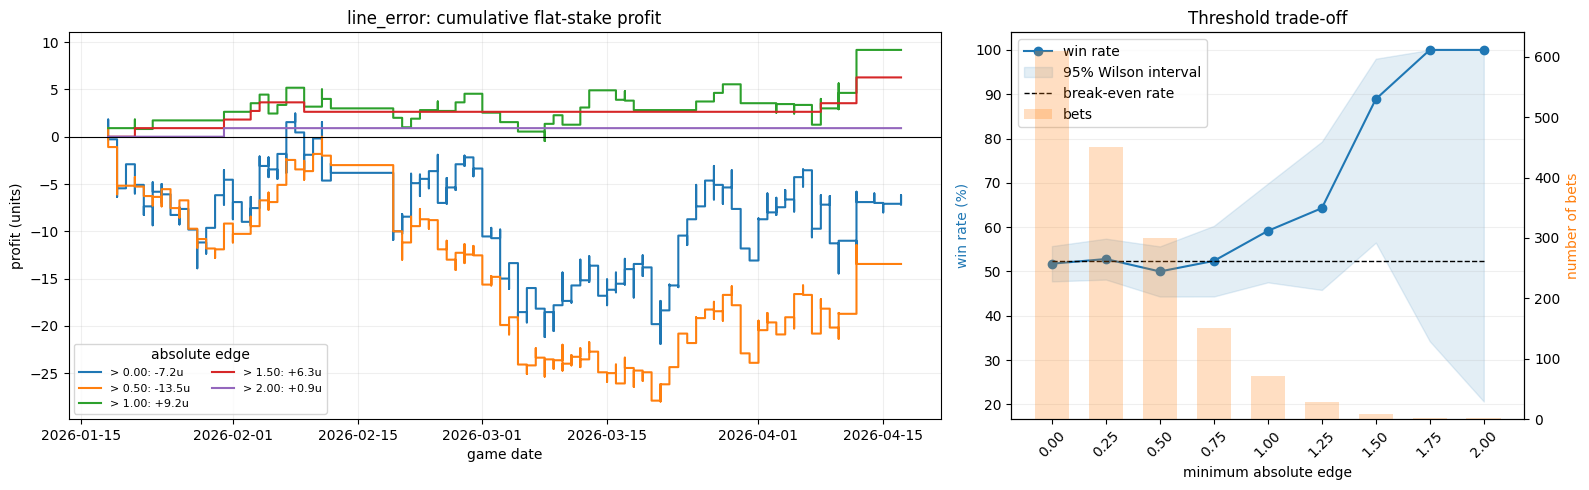

Line-error results above are ready to inspect; continuing with total_points and spread_error.

Starting total_points...


total_points:   0%|          | 0/81 [00:00<?, ?it/s]

Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 

,games,game_dates,start,end,mae,rmse,r2,baseline_mae
target,,,,,,,,
total_points,610,81,2026-01-18,2026-04-17,14.3929,18.2959,0.1712,14.4074


,min_edge,n_bets,bet_rate,wins,losses,pushes,win_rate,ci_low,ci_high,break_even,profit_units,roi
0,0.00,610,1.0000,313,286,11,0.5225,0.4825,0.5623,0.5238,-1.4545,-0.0024
1,0.25,440,0.7213,223,209,8,0.5162,0.4691,0.5630,0.5238,-6.2727,-0.0143
2,0.50,310,0.5082,164,141,5,0.5377,0.4816,0.5928,0.5238,8.0909,0.0261
3,0.75,202,0.3311,108,92,2,0.5400,0.4708,0.6077,0.5238,6.1818,0.0306
4,1.00,123,0.2016,63,59,1,0.5164,0.4286,0.6032,0.5238,-1.7273,-0.0140
5,1.25,79,0.1295,38,40,1,0.4872,0.3795,0.5961,0.5238,-5.4545,-0.0690
6,1.50,36,0.0590,17,19,0,0.4722,0.3199,0.6299,0.5238,-3.5455,-0.0985
7,1.75,19,0.0311,10,9,0,0.5263,0.3171,0.7267,0.5238,0.0909,0.0048
8,2.00,9,0.0148,6,3,0,0.6667,0.3542,0.8794,0.5238,2.4545,0.2727


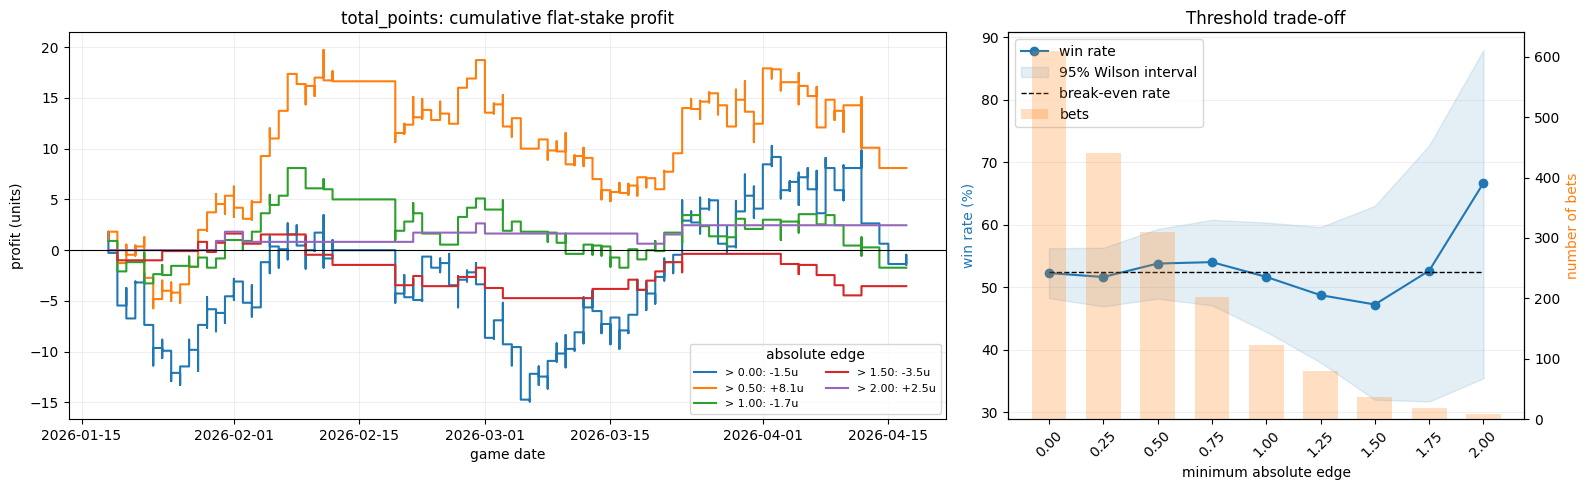


Starting spread_error...


spread_error:   0%|          | 0/81 [00:00<?, ?it/s]

Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 on CUDA
Using local TabPFN model v3 

,games,game_dates,start,end,mae,rmse,r2,baseline_mae
target,,,,,,,,
spread_error,610,81,2026-01-18,2026-04-17,11.0066,14.1494,0.004,11.0311


,min_edge,n_bets,bet_rate,wins,losses,pushes,win_rate,ci_low,ci_high,break_even,profit_units,roi
0,0.00,610,1.0000,302,302,6,0.5000,0.4603,0.5397,0.5236,-27.26,-0.0447
1,0.25,316,0.5180,156,157,3,0.4984,0.4434,0.5535,0.5236,-15.12,-0.0478
2,0.50,144,0.2361,70,72,2,0.4930,0.4120,0.5743,0.5237,-8.38,-0.0582
3,0.75,67,0.1098,34,33,0,0.5075,0.3906,0.6235,0.5237,-2.10,-0.0313
4,1.00,47,0.0770,23,24,0,0.4894,0.3528,0.6276,0.5238,-3.11,-0.0662
5,1.25,36,0.0590,19,17,0,0.5278,0.3701,0.6801,0.5239,0.25,0.0069
6,1.50,20,0.0328,9,11,0,0.4500,0.2582,0.6579,0.5241,-2.85,-0.1425
7,1.75,15,0.0246,7,8,0,0.4667,0.2481,0.6988,0.5243,-1.67,-0.1113
8,2.00,11,0.0180,6,5,0,0.5455,0.2801,0.7873,0.5246,0.42,0.0382


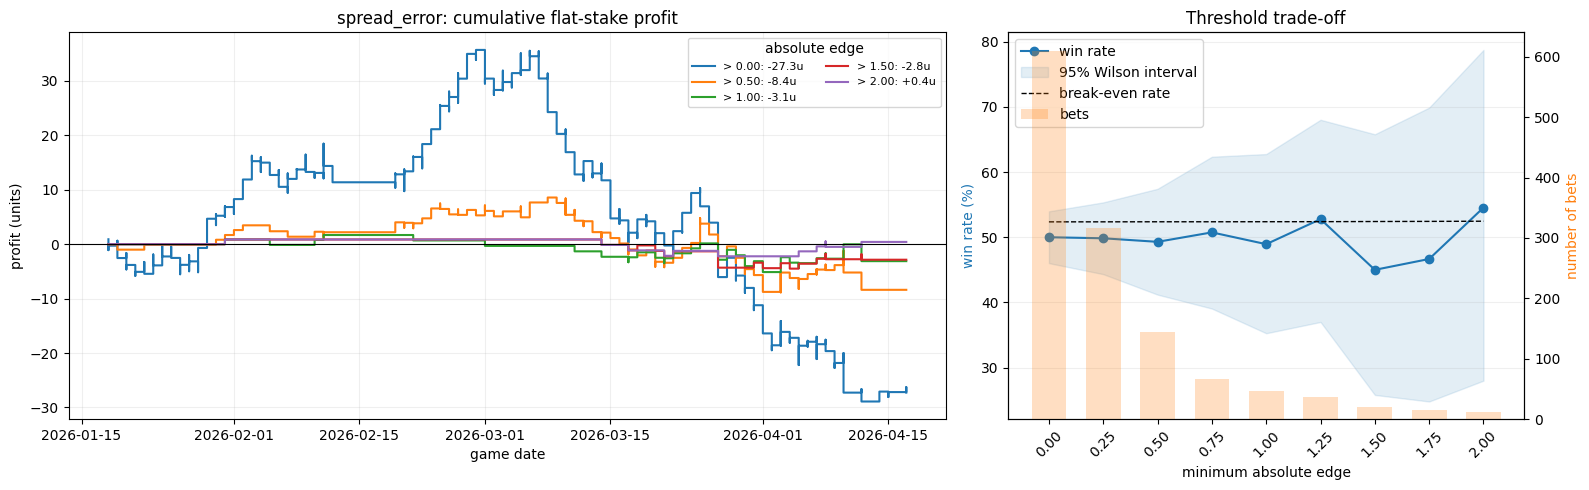

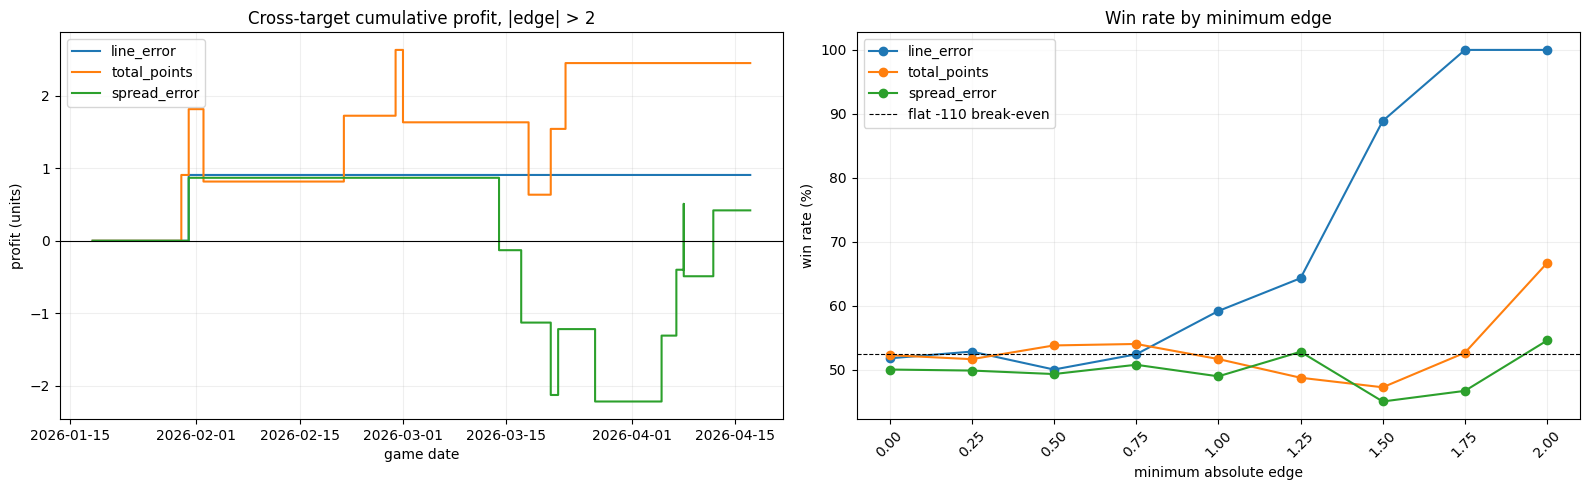

In [19]:
def add_bet_profit(predictions: pd.DataFrame, threshold: float) -> pd.DataFrame:
    out = predictions.copy()
    edge = out["predicted_edge"].to_numpy(dtype=float)
    actual = out["actual_edge"].to_numpy(dtype=float)
    placed = np.abs(edge) > threshold
    push = actual == 0
    won = np.where(edge > 0, actual > 0, actual < 0) & placed & ~push
    lost = placed & ~won & ~push
    price = np.where(edge > 0, out["positive_price"], out["negative_price"]).astype(float)
    out["profit"] = np.where(won, price - 1.0, np.where(lost, -1.0, 0.0))
    out["cumulative_profit"] = out["profit"].cumsum()
    return out


def display_target_results(
    target_name: str, predictions: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame]:
    spec = TARGET_SPECS[target_name]
    regression, betting = target_evaluation_tables(predictions, spec)
    regression.to_csv(OUTPUT_DIR / f"{target_name}_regression_summary.csv")
    betting.to_csv(OUTPUT_DIR / f"{target_name}_betting_thresholds.csv", index=False)

    print(f"\n{target_name} complete: {len(predictions)} predictions", flush=True)
    display(regression.round(4))
    display(betting.round(4))

    fig, (profit_axis, threshold_axis) = plt.subplots(
        1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.7, 1]}
    )
    for threshold in PLOT_EDGE_THRESHOLDS:
        plotted = add_bet_profit(predictions, threshold)
        final_profit = plotted["cumulative_profit"].iloc[-1]
        profit_axis.step(
            plotted[DATE_COL],
            plotted["cumulative_profit"],
            where="post",
            label=f"> {threshold:.2f}: {final_profit:+.1f}u",
        )
    profit_axis.axhline(0, color="black", linewidth=0.8)
    profit_axis.set_title(f"{target_name}: cumulative flat-stake profit")
    profit_axis.set_xlabel("game date")
    profit_axis.set_ylabel("profit (units)")
    profit_axis.grid(alpha=0.2)
    profit_axis.legend(title="absolute edge", ncol=2, fontsize=8)

    threshold_values = betting["min_edge"].to_numpy(dtype=float)
    win_percent = 100.0 * betting["win_rate"].to_numpy(dtype=float)
    ci_low_percent = 100.0 * betting["ci_low"].to_numpy(dtype=float)
    ci_high_percent = 100.0 * betting["ci_high"].to_numpy(dtype=float)
    break_even_percent = 100.0 * betting["break_even"].to_numpy(dtype=float)
    threshold_axis.plot(
        threshold_values, win_percent, color="tab:blue", marker="o", label="win rate"
    )
    threshold_axis.fill_between(
        threshold_values, ci_low_percent, ci_high_percent,
        color="tab:blue", alpha=0.12, label="95% Wilson interval"
    )
    threshold_axis.plot(
        threshold_values, break_even_percent, color="black", linestyle="--",
        linewidth=1.0, label="break-even rate"
    )
    threshold_axis.set_title("Threshold trade-off")
    threshold_axis.set_xlabel("minimum absolute edge")
    threshold_axis.set_ylabel("win rate (%)", color="tab:blue")
    threshold_axis.set_xticks(EDGE_THRESHOLDS)
    threshold_axis.tick_params(axis="x", rotation=45)
    threshold_axis.grid(axis="y", alpha=0.2)
    bet_axis = threshold_axis.twinx()
    bet_axis.bar(
        threshold_values,
        betting["n_bets"].to_numpy(dtype=int),
        width=0.16,
        color="tab:orange",
        alpha=0.25,
        label="bets",
    )
    bet_axis.set_ylabel("number of bets", color="tab:orange")
    handles_left, labels_left = threshold_axis.get_legend_handles_labels()
    handles_right, labels_right = bet_axis.get_legend_handles_labels()
    threshold_axis.legend(
        handles_left + handles_right, labels_left + labels_right, loc="best"
    )
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{target_name}_diagnostics.png",
        dpi=150,
        bbox_inches="tight",
    )
    display(fig)
    plt.close(fig)
    return regression, betting


# Colab has one GPU kernel, so targets fit sequentially. Outputs are emitted
# after each target; line-error remains visible while the other two compute.
EXPECTED_TARGET_ORDER = ("line_error", "total_points", "spread_error")
if tuple(TARGETS_TO_RUN) != EXPECTED_TARGET_ORDER:
    raise ValueError(f"TARGETS_TO_RUN must remain ordered as {EXPECTED_TARGET_ORDER}.")

predictions_by_target = {}
regression_by_target = {}
betting_by_target = {}
for target_name in TARGETS_TO_RUN:
    print(f"\nStarting {target_name}...", flush=True)
    predictions = run_walk_forward(
        df, TARGET_SPECS[target_name], feature_sets[target_name], test_dates
    )
    predictions_by_target[target_name] = predictions
    regression_by_target[target_name], betting_by_target[target_name] = (
        display_target_results(target_name, predictions)
    )
    if target_name == "line_error":
        print(
            "Line-error results above are ready to inspect; "
            "continuing with total_points and spread_error.",
            flush=True,
        )

regression_results = pd.concat(
    [regression_by_target[name] for name in TARGETS_TO_RUN]
)
betting_results = pd.concat(
    {name: betting_by_target[name] for name in TARGETS_TO_RUN},
    names=["target", "row"],
).reset_index(level="row", drop=True)
regression_results.to_csv(OUTPUT_DIR / "regression_summary.csv")
betting_results.to_csv(OUTPUT_DIR / "betting_thresholds.csv")

fig, (profit_axis, win_axis) = plt.subplots(1, 2, figsize=(16, 5))
for target_name in TARGETS_TO_RUN:
    plotted = add_bet_profit(predictions_by_target[target_name], PRIMARY_EDGE)
    profit_axis.step(
        plotted[DATE_COL],
        plotted["cumulative_profit"],
        where="post",
        label=target_name,
    )
    target_betting = betting_by_target[target_name]
    win_axis.plot(
        target_betting["min_edge"],
        100.0 * target_betting["win_rate"],
        marker="o",
        label=target_name,
    )
profit_axis.axhline(0, color="black", linewidth=0.8)
profit_axis.set_title(
    f"Cross-target cumulative profit, |edge| > {PRIMARY_EDGE:g}"
)
profit_axis.set_xlabel("game date")
profit_axis.set_ylabel("profit (units)")
profit_axis.grid(alpha=0.2)
profit_axis.legend()
win_axis.axhline(100.0 / DECIMAL_ODDS, color="black", linestyle="--", linewidth=0.8, label="flat -110 break-even")
win_axis.set_title("Win rate by minimum edge")
win_axis.set_xlabel("minimum absolute edge")
win_axis.set_ylabel("win rate (%)")
win_axis.set_xticks(EDGE_THRESHOLDS)
win_axis.tick_params(axis="x", rotation=45)
win_axis.grid(alpha=0.2)
win_axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cross_target_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## Reading the result

Compare `mae` with `baseline_mae`, then inspect win rate, its Wilson interval, ROI, and bet count at the same edge threshold across targets. A 90-day sample is useful as an out-of-sample engineering check, but it is usually too small to establish profitability: at -110 the break-even win rate is 52.38%, and the confidence interval will normally remain wide.

This notebook deliberately tests closing lines only. Intermediate snapshots and their line-history features should be a separate experiment so the prediction-time line and settlement line cannot be mixed accidentally.